In [3]:
# ==========================
# Imports and Setup
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import sent_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import umap
import textstat

sns.set_style("whitegrid")

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
# --------------
# Load the Data
# --------------

df = pd.read_csv("ASAP2_train_sourcetexts.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (24728, 14)


,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


In [5]:
# ---------------
# Basic Info
# ---------------
df.info()
df.describe()
print(df['score'].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24728 entries, 0 to 24727
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   essay_id                    24728 non-null  object
 1   score                       24728 non-null  int64 
 2   full_text                   24728 non-null  object
 3   assignment                  24728 non-null  object
 4   prompt_name                 24728 non-null  object
 5   economically_disadvantaged  20723 non-null  object
 6   student_disability_status   20723 non-null  object
 7   ell_status                  24286 non-null  object
 8   race_ethnicity              24724 non-null  object
 9   gender                      24728 non-null  object
 10  source_text_1               24728 non-null  object
 11  source_text_2               4005 non-null   object
 12  source_text_3               4005 non-null   object
 13  source_text_4               1959 non-null   ob

In [6]:
# ====================
# Feature Engineering
# ====================

nltk.download('punkt_tab')

# Word Count Feature
df["word_count"] = df["full_text"].astype(str).apply(lambda x: len(x.split()))

# Sentence Count Feature
df["sentence_count"] = df["full_text"].astype(str).apply(lambda x: len(sent_tokenize(x)))

# Average Sentence Length
df["avg_sentence_length"] = df["word_count"] / df["sentence_count"]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [7]:
print(df[['full_text', 'word_count', 'sentence_count', 'avg_sentence_length']].head())

                                           full_text  word_count  \
0  The author suggests that studying Venus is wor...         396   
1  NASA is fighting to be alble to to go to Venus...         200   
2  "The Evening Star", is one of the brightest po...         371   
3  The author supports this idea because from rea...         224   
4  How the author supports this idea is that he s...         219   

   sentence_count  avg_sentence_length  
0              17            23.294118  
1              10            20.000000  
2              31            11.967742  
3              10            22.400000  
4               7            31.285714  


In [8]:
# --------------------
# Vocabulary Richness
# --------------------

def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df["vocab_richness"] = df["full_text"].astype(str).apply(vocab_richness)

In [9]:
# =====================
# Readability Score
# =====================

df["readability"] = df["full_text"].astype(str).apply(textstat.flesch_kincaid_grade)

In [10]:
# ================
# Semantic Themes
# ================

# Vectorize Essays
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(df["full_text"].astype(str))

# Train LDA
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42
)

lda.fit(X)

# Extract Topic Words
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic {topic_idx + 1}")
    print([words[i] for i in topic.argsort()[-10:]])


# --------------------
# Semantic Embeddings
# --------------------

# Load Sentence Embedding Model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate Embeddings
embeddings = model.encode(
    df["full_text"].astype(str).tolist(),
    show_progress_bar=True
)

# Cluster Essays by Meaning
kmeans = KMeans(n_clusters=8, random_state=42)

df["semantic_cluster"] = kmeans.fit_predict(embeddings)


Topic 1
['usage', 'help', 'just', 'gas', 'world', 'use', 'money', 'people', 'cars', 'car']

Topic 2
['image', 'just', 'mesa', 'alien', 'nasa', 'natural', 'picture', 'landform', 'mars', 'face']

Topic 3
['popular', 'state', 'votes', 'electors', 'states', 'people', 'president', 'college', 'vote', 'electoral']

Topic 4
['coding', 'like', 'classroom', 'student', 'computer', 'facial', 'help', 'emotions', 'technology', 'students']

Topic 5
['life', 'landform', 'nasa', 'think', 'people', 'like', 'aliens', 'just', 'mars', 'face']

Topic 6
['human', 'think', 'technology', 'drive', 'people', 'driving', 'driver', 'driverless', 'car', 'cars']

Topic 7
['things', 'join', 'cowboys', 'fun', 'animals', 'help', 'program', 'like', 'seagoing', 'people']

Topic 8
['program', 'time', 'europe', 'help', 'people', 'cowboy', 'cowboys', 'animals', 'seagoing', 'luke']

Topic 9
['nasa', 'study', 'dangers', 'humans', 'surface', 'like', 'author', 'earth', 'planet', 'venus']

Topic 10
['air', 'paris', 'pollution', 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/773 [00:00<?, ?it/s]

In [11]:
# ===========================
# Source Text Similarities
# ===========================

source_embeddings = model.encode(
    df["source_text_1"].astype(str).tolist()
)

# Computer Similarities
similarities = []

for i in range(len(embeddings)):
    sim = cosine_similarity(
        [embeddings[i]],
        [source_embeddings[i]]
    )[0][0]

    similarities.append(sim)

df["source_similarity"] = similarities

KeyboardInterrupt: 

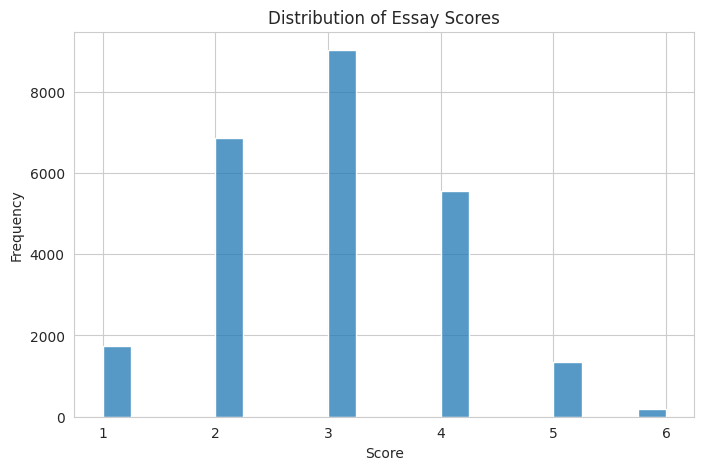

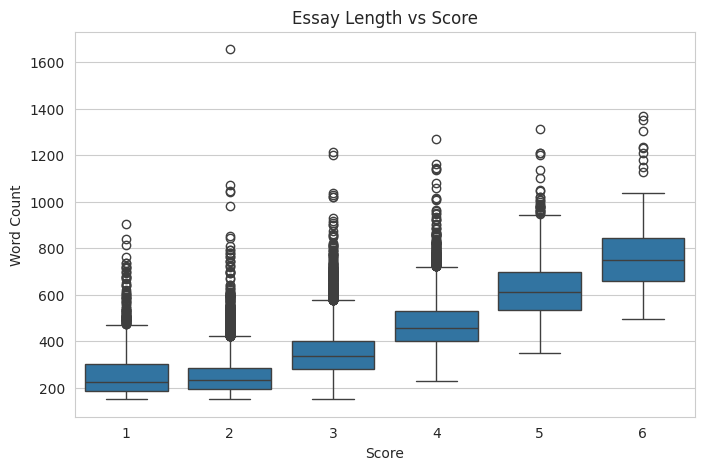

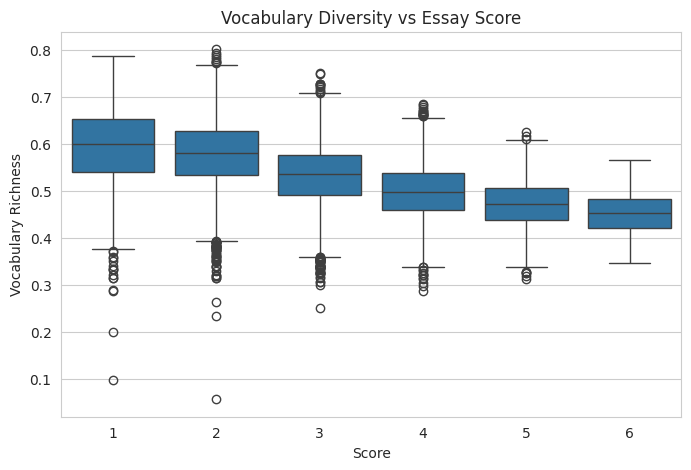

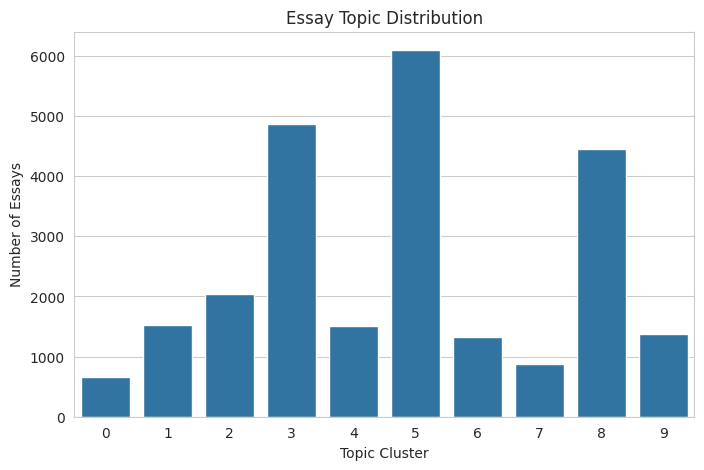

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


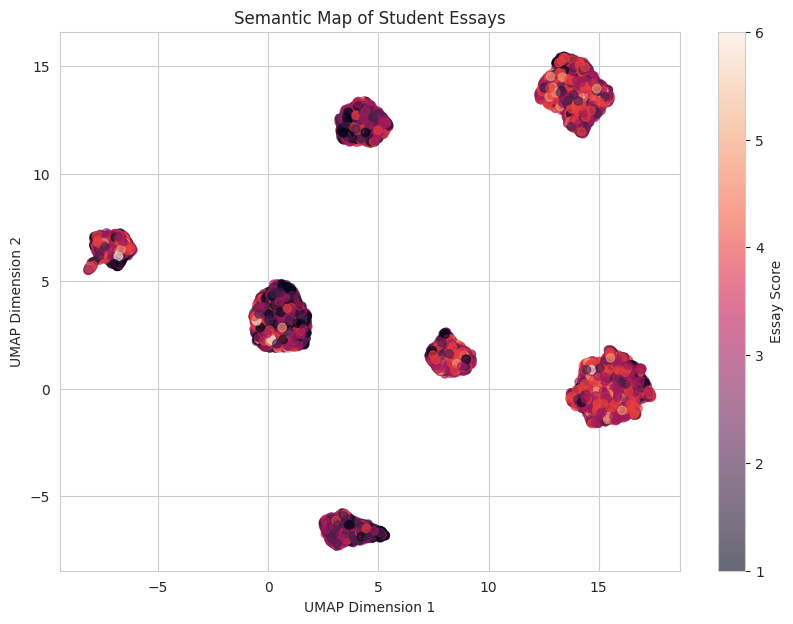

ValueError: Could not interpret value `source_similarity` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [12]:
# ===============
# Visualizations
# ===============

# Score Distribtuion
plt.figure(figsize=(8,5))

sns.histplot(df["score"], bins=20)

plt.title("Distribution of Essay Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

# Word Count vs Score
plt.figure(figsize=(8,5))

sns.boxplot(x="score", y="word_count", data=df)

plt.title("Essay Length vs Score")
plt.xlabel("Score")
plt.ylabel("Word Count")

plt.show()

# Vocabulary Richness vs. Score
plt.figure(figsize=(8,5))

sns.boxplot(x="score", y="vocab_richness", data=df)

plt.title("Vocabulary Diversity vs Essay Score")
plt.xlabel("Score")
plt.ylabel("Vocabulary Richness")

plt.show()

# Topic Distribution
# Dominant Topic Assignment
topic_probs = lda.transform(X)
df["topic"] = topic_probs.argmax(axis=1)
# Plot Frequency
plt.figure(figsize=(8,5))

sns.countplot(x="topic", data=df)

plt.title("Essay Topic Distribution")
plt.xlabel("Topic Cluster")
plt.ylabel("Number of Essays")

plt.show()

# Semantic Essay Map (UMAP)
#Dimension Reduction
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)
# Plot Clusters
plt.figure(figsize=(10,7))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df["score"],
    alpha=0.6
)

plt.title("Semantic Map of Student Essays")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.colorbar(label="Essay Score")

plt.show()

# Source vs. Similarity Score
plt.figure(figsize=(8,5))

sns.boxplot(x="score", y="source_similarity", data=df)

plt.title("Source Text Similarity vs Essay Score")
plt.xlabel("Score")
plt.ylabel("Semantic Similarity")

plt.show()

In [14]:
# ---------------
# Save Features
# ---------------

features = df[[
    "score",
    "word_count",
    "sentence_count",
    "avg_sentence_length",
    "vocab_richness",
    "readability",
    "topic",
    "semantic_cluster"
]]

features.to_csv("essay_features_engineered.csv", index=False)